In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Q1. Reading the Dataset

df = pd.read_csv("carprice.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compres


Dataset Shape: (199, 26)
Number of Rows: 199
Number of Columns: 26

Statistical Summary:
        symboling  wheel-base      length       width      height  \
count  199.000000  199.000000  199.000000  199.000000  199.000000   
mean     0.788945   98.852764  174.099497   65.905528   53.816583   
std      1.220895    6.085940   12.489391    2.176300    2.395002   
min     -2.000000   86.600000  141.100000   60.300000   47.800000   
25%      0.000000   94.500000  166.300000   64.000000   52.000000   
50%      1.000000   97.000000  173.200000   65.400000   54.100000   
75%      2.000000  102.400000  183.500000   66.900000   55.550000   
max      3.000000  120.900000  208.100000   72.300000   59.800000   

       curb-weight  engine-size        bore      stroke  compression-ratio  \
count   199.000000   199.000000  199.000000  199.000000         199.000000   
mean   2558.829146   127.949749    3.328442    3.248945          10.171960   
std     528.005482    41.534670    0.274602    0.31158

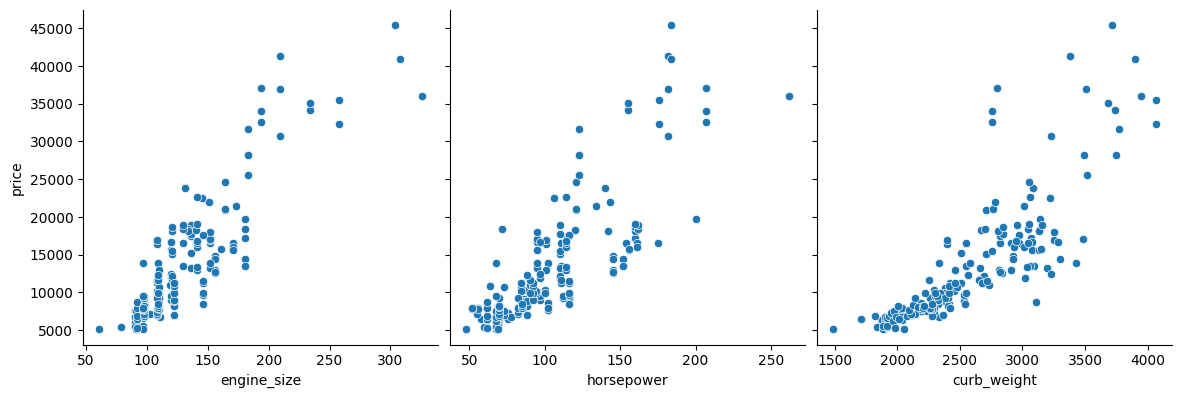

In [8]:
# Q2. Exploratory Data Analysis

print("\nDataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nStatistical Summary:")
print(df.describe())

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# Correct and standardize column names

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Rename columns used in the original car dataset
rename_columns = {
    "carid": "car_id",
    "carname": "car_name",
    "fueltype": "fuel_type",
    "doornumber": "num_doors",
    "drivewheel": "drive_wheels",
    "enginelocation": "engine_location",
    "wheelbase": "wheel_base",
    "carlength": "length",
    "carwidth": "width",
    "carheight": "height",
    "curbweight": "curb_weight",
    "enginetype": "engine_type",
    "cylindernumber": "num_cylinders",
    "enginesize": "engine_size",
    "fuelsystem": "fuel_system",
    "boreratio": "bore",
    "compressionratio": "compression_ratio",
    "peakrpm": "peak_rpm",
    "citympg": "city_mpg",
    "highwaympg": "highway_mpg",
    "carbody": "car_body",
    "normalizedlosses": "normalized_losses"
}

df.rename(columns=rename_columns, inplace=True)

print("\nCorrected Column Names:")
print(df.columns.tolist())


# Convert numerical columns to numeric types

numeric_columns = [
    "symboling", "normalized_losses",
    "wheel_base", "length", "width",
    "height", "curb_weight", "engine_size",
    "bore", "stroke", "compression_ratio",
    "horsepower", "peak_rpm",
    "city_mpg", "highway_mpg", "price"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].replace("?", np.nan),
            errors="coerce"
        )

# Remove records with missing target prices
df.dropna(subset=["price"], inplace=True)


# Pairwise relationships

sns.pairplot(
    df,
    x_vars=["engine_size", "horsepower", "curb_weight"],
    y_vars=["price"],
    kind="scatter",
    height=4
)

plt.show()



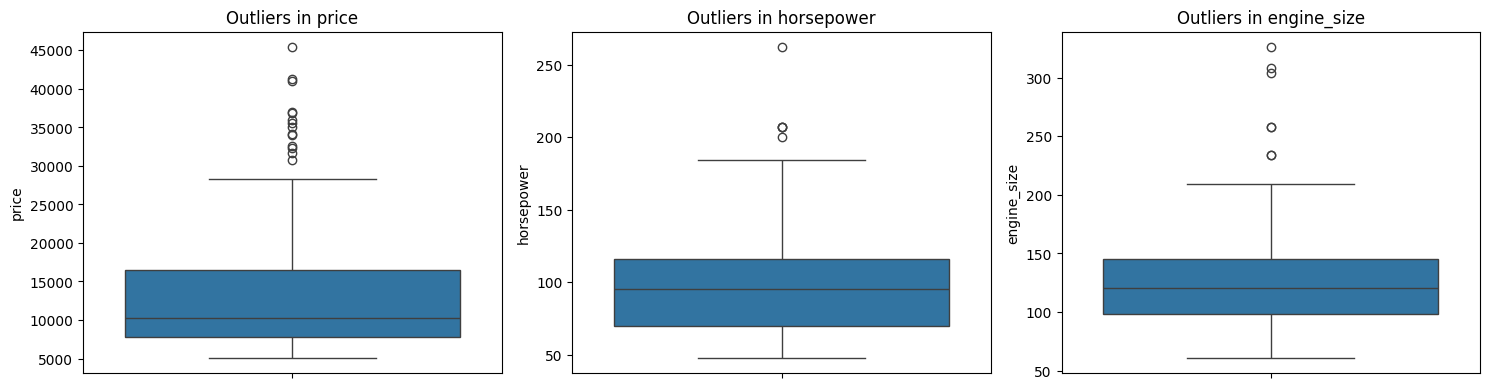


Outliers in price: 14

Outliers in horsepower: 5

Outliers in engine_size: 7


In [9]:

# Q3. Data Preprocessing

# Check outliers using boxplots

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(
    axes,
    ["price", "horsepower", "engine_size"]
):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title("Outliers in " + col)

plt.tight_layout()
plt.show()


# Detect outliers using IQR

for col in ["price", "horsepower", "engine_size"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"\nOutliers in {col}: {len(outliers)}")

# Retain outliers because expensive and powerful
# cars may legitimately have extreme values.


# Remove unnecessary identifier columns

df.drop(
    columns=["car_id", "car_name"],
    errors="ignore",
    inplace=True
)



In [10]:

# Q4. Splitting the Data

X = df.drop(columns=["price"])
y = df["price"]

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining and Testing Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# Handle missing values and scale numerical data

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Handle categorical variables using one-hot encoding

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])



Numerical Features:
['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg']

Categorical Features:
['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders', 'fuel_system']

Training and Testing Shapes:
X_train: (156, 25)
X_test: (39, 25)
y_train: (156,)
y_test: (39,)


In [11]:


# Q5. Building Linear Regression Model

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

regressor = model.named_steps["regressor"]

print("\nIntercept:")
print(regressor.intercept_)

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

print("\nCoefficients:")
print(coefficients.to_string(index=False))




Intercept:
21241.265320164734

Coefficients:
                     Feature  Coefficient
              num__symboling  -281.512645
      num__normalized_losses  -100.023145
             num__wheel_base  1317.076557
                 num__length -1830.223006
                  num__width   734.735436
                 num__height  -807.855977
            num__curb_weight  4610.126743
            num__engine_size   734.952044
                   num__bore  -404.528514
                 num__stroke  -140.071526
      num__compression_ratio -1332.543903
             num__horsepower   319.789316
               num__peak_rpm   446.436176
               num__city_mpg  -148.363400
            num__highway_mpg   601.628957
       cat__make_alfa-romero  1208.170468
              cat__make_audi  3191.950170
               cat__make_bmw  5739.955494
         cat__make_chevrolet   610.533244
             cat__make_dodge -3474.783564
             cat__make_honda  -419.673470
             cat__make_isuzu -


Model Evaluation:
Mean Squared Error: 12932353.0977753
R2 Score: 0.8933593050079496

Actual vs Predicted Prices:
    Actual Price  Predicted Price
0         8013.0      7594.812789
1        36880.0     31546.475732
2         9298.0      8120.274575
3        13499.0     14230.814185
4        16503.0     19801.855180
5         8058.0      7337.635740
6        10245.0     10874.899544
7        41315.0     28729.618931
8         7957.0      9591.238564
9         5572.0      6925.466255
10       12940.0     15614.798257
11        6295.0      9418.442114
12        5499.0      6049.462116
13       16430.0     17832.472333
14       10698.0     11436.077483
15       12764.0     15946.345517
16        5389.0      5531.162328
17        6229.0      7906.000286
18       21485.0     15866.881853
19       32528.0     33933.018833
20       12170.0     14901.945431
21        7898.0      3980.993099
22       40960.0     36590.026498
23       35550.0     32362.385827
24        9639.0     10416.762218
25

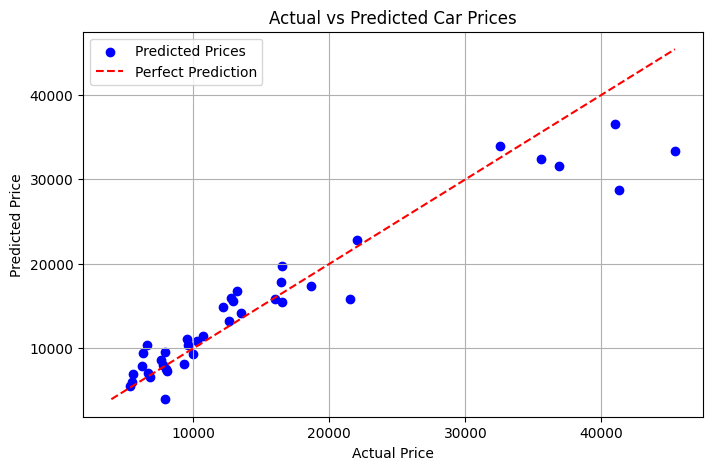

In [12]:

# Q6. Model Evaluation

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

results = pd.DataFrame({
    "Actual Price": y_test.to_numpy(),
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Prices:")
print(results)


# Plot actual vs predicted prices

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    label="Predicted Prices"
)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.legend()
plt.grid(True)
plt.show()


In [13]:


# Q7. Testing on Unseen Data

new_car = {
    "symboling": 3,
    "normalized_losses": 100,
    "fuel_type": "gas",
    "aspiration": "std",
    "num_doors": "four",
    "drive_wheels": "fwd",
    "engine_location": "front",
    "wheel_base": 88.6,
    "length": 168.8,
    "width": 64.1,
    "height": 48.8,
    "curb_weight": 2548,
    "engine_type": "dohc",
    "num_cylinders": "four",
    "engine_size": 130,
    "fuel_system": "mpfi",
    "bore": 3.47,
    "stroke": 2.68,
    "compression_ratio": 9,
    "horsepower": 111,
    "peak_rpm": 5000,
    "city_mpg": 21,
    "highway_mpg": 27
}

new_car_df = pd.DataFrame([new_car])

# Align unseen data with training features
new_car_df = new_car_df.reindex(columns=X.columns)

predicted_price = model.predict(new_car_df)

print("\nPredicted Price for New Car:")
print(f"${predicted_price[0]:,.2f}")


Predicted Price for New Car:
$8,531.58
